# Logistic Regression: Deep Dive
## Loan Default Prediction (HMEQ Dataset)

*Part of the [ML Model Comparison](../loan_default_tradeoff_matrix.html) series on bitterscientist.com*

This notebook covers:
1. The math behind logistic regression (full derivation)
2. Worked examples using actual HMEQ data
3. Model training with hyperparameter tuning
4. Diagnostic visualizations (exported as interactive plotly HTML)
5. Results interpretation

---
## 1. Setup

In [1]:
import sys
sys.path.insert(0, ".")
from shared_utils import *

# Additional imports for this notebook
from sklearn.linear_model import LogisticRegression
import scipy.stats as stats

MODEL_NAME = "Logistic Regression"
MODEL_SLUG = "logistic_regression"

# Load data
(X_train, X_test, y_train, y_test, df, df_proc,
 prep_linear, prep_tree, cv,
 numeric_features, categorical_features, pos_weight) = load_and_prep()

Dataset loaded: 5960 rows, 13 columns
Default rate: 19.95%
Train: 4470 | Test: 1490
Numeric features: 15 | Categorical: 2
Positive class weight: 4.01


---
## 2. The Math Behind Logistic Regression

### 2.1 The Problem

We want to predict $P(Y=1 \mid \mathbf{x})$ — the probability that a borrower defaults given their features. Linear regression cannot do this because it outputs unbounded values, not probabilities in $[0, 1]$.

### 2.2 The Sigmoid (Logistic) Function

The key insight is to model the **log-odds** (logit) of default as a linear function, then transform back to probability.

**The logit transformation:**

$$\text{logit}(p) = \ln\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_k x_k$$

where $p = P(Y=1 \mid \mathbf{x})$ and $\frac{p}{1-p}$ is the **odds ratio**.

**Solving for $p$:**

$$p = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \cdots + \beta_k x_k)}} = \sigma(z)$$

This is the **sigmoid function** $\sigma(z) = \frac{1}{1+e^{-z}}$, which maps any real number $z \in (-\infty, +\infty)$ to a probability $p \in (0, 1)$.

### 2.3 Properties of the Sigmoid

| Input $z$ | Output $\sigma(z)$ | Interpretation |
|-----------|-------------------|----------------|
| $z \to -\infty$ | $\sigma(z) \to 0$ | Very unlikely to default |
| $z = 0$ | $\sigma(z) = 0.5$ | Equal odds |
| $z \to +\infty$ | $\sigma(z) \to 1$ | Very likely to default |

**Derivative:** $\sigma'(z) = \sigma(z)(1 - \sigma(z))$, which is maximized at $z=0$ and approaches 0 at the extremes. This means the model is most "sensitive" to feature changes near the decision boundary.

### 2.4 Maximum Likelihood Estimation

We cannot use ordinary least squares (OLS) because the target is binary. Instead, we find $\boldsymbol{\beta}$ by maximizing the **likelihood** — the probability of observing the actual outcomes given the model.

For a single observation $(x_i, y_i)$:

$$P(Y=y_i \mid \mathbf{x}_i) = p_i^{y_i} (1-p_i)^{1-y_i}$$

where $p_i = \sigma(\mathbf{x}_i^T \boldsymbol{\beta})$.

For all $n$ observations (assuming independence):

$$L(\boldsymbol{\beta}) = \prod_{i=1}^{n} p_i^{y_i} (1-p_i)^{1-y_i}$$

Taking the log (the **log-likelihood**):

$$\ell(\boldsymbol{\beta}) = \sum_{i=1}^{n} \left[ y_i \ln(p_i) + (1-y_i) \ln(1-p_i) \right]$$

### 2.5 The Loss Function (Binary Cross-Entropy)

Minimizing the **negative** log-likelihood gives us the **binary cross-entropy** loss:

$$J(\boldsymbol{\beta}) = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \ln(p_i) + (1-y_i) \ln(1-p_i) \right]$$

This is what the optimizer (L-BFGS, Newton's method, or gradient descent) minimizes.

**Gradient (for one coefficient $\beta_j$):**

$$\frac{\partial J}{\partial \beta_j} = \frac{1}{n} \sum_{i=1}^{n} (p_i - y_i) x_{ij}$$

There is **no closed form solution** — we must use iterative optimization. The Hessian is negative semi-definite, so the log-likelihood is concave and has a unique maximum.

### 2.6 Regularization

To prevent overfitting, sklearn adds an L2 penalty by default:

$$J_{\text{regularized}}(\boldsymbol{\beta}) = J(\boldsymbol{\beta}) + \frac{1}{2C} \|\boldsymbol{\beta}\|_2^2$$

where $C$ is the **inverse regularization strength**. Smaller $C$ means stronger regularization (shrink coefficients toward zero). Larger $C$ means less regularization (closer to unregularized MLE).

### 2.7 Class Weights

With `class_weight="balanced"`, sklearn adjusts the loss so that each class contributes equally regardless of frequency:

$$w_k = \frac{n}{2 \cdot n_k}$$

For HMEQ with ~80% good / ~20% default:
- $w_0 = \frac{n}{2 \cdot n_0} \approx 0.625$ (down-weight majority)
- $w_1 = \frac{n}{2 \cdot n_1} \approx 2.5$ (up-weight minority)

This makes misclassifying a defaulter 4x more costly than misclassifying a good borrower in the loss function.

---
## 3. Visualizing the Sigmoid Function

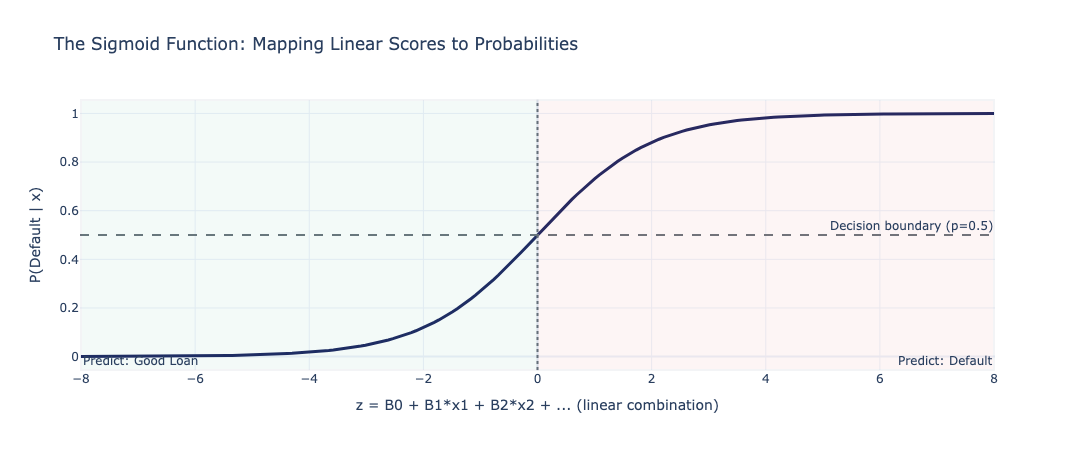

  Saved: outputs/logistic_regression/sigmoid_function.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/logistic_regression/sigmoid_function.html')

In [2]:
# Plot the sigmoid function
z = np.linspace(-8, 8, 200)
sigma = 1 / (1 + np.exp(-z))

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=z, y=sigma, mode="lines",
    name="sigmoid(z) = 1/(1+e^(-z))",
    line=dict(color=COLORS["navy"], width=3),
))
fig.add_hline(y=0.5, line_dash="dash", line_color=COLORS["gray"],
              annotation_text="Decision boundary (p=0.5)")
fig.add_vline(x=0, line_dash="dot", line_color=COLORS["gray"])

# Shade regions
fig.add_vrect(x0=-8, x1=0, fillcolor=COLORS["green"], opacity=0.05,
              annotation_text="Predict: Good Loan", annotation_position="bottom left")
fig.add_vrect(x0=0, x1=8, fillcolor=COLORS["red"], opacity=0.05,
              annotation_text="Predict: Default", annotation_position="bottom right")

fig.update_layout(
    title="The Sigmoid Function: Mapping Linear Scores to Probabilities",
    xaxis_title="z = B0 + B1*x1 + B2*x2 + ... (linear combination)",
    yaxis_title="P(Default | x)",
    height=450, width=700,
)
fig.show()
save_chart(fig, MODEL_SLUG, "sigmoid_function")

---
## 4. Worked Example with HMEQ Data

Let's manually walk through the logistic regression prediction for real borrowers from the dataset.

In [3]:
# First, train the model so we have actual coefficients
lr_pipe = Pipeline([
    ("prep", prep_linear),
    ("clf", LogisticRegression(
        class_weight="balanced", max_iter=2000,
        random_state=RANDOM_STATE, solver="lbfgs", C=1.0
    )),
])
lr_pipe.fit(X_train, y_train)

# Extract the fitted model
lr_model = lr_pipe.named_steps["clf"]
preprocessor = lr_pipe.named_steps["prep"]

# Get feature names after transformation
num_names = numeric_features
cat_encoder = preprocessor.named_transformers_["cat"]
cat_names = list(cat_encoder.get_feature_names_out(categorical_features))
all_feature_names = num_names + cat_names

print(f"Intercept (B0): {lr_model.intercept_[0]:.4f}")
print(f"Number of coefficients: {len(lr_model.coef_[0])}")
print(f"\nTop 10 coefficients by absolute value:")
coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": lr_model.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)
print(coef_df.head(10).to_string(index=False))

Intercept (B0): -0.4078
Number of coefficients: 25

Top 10 coefficients by absolute value:
        feature  coefficient
DEBTINC_missing     1.093226
      JOB_Sales     1.009299
        JOB_nan    -1.002558
         DELINQ     0.881197
     JOB_Office    -0.788232
        DEBTINC     0.502953
       JOB_Self     0.479476
          DEROG     0.427793
          CLAGE    -0.384402
  DEROG_missing    -0.362864


In [4]:
# Pick 3 example borrowers
examples = get_example_rows(df, n=3)

print("=" * 70)
print("WORKED EXAMPLE: Manual Logistic Regression Prediction")
print("=" * 70)

for idx, row in examples.iterrows():
    print_example_row(row, idx)

    # Transform through preprocessor
    row_df = pd.DataFrame([row.drop(TARGET)])
    # Fill in missing flag columns
    for c in [col for col in df_proc.columns if col.endswith("_missing")]:
        base_col = c.replace("_missing", "")
        if base_col in row_df.columns:
            row_df[c] = row_df[base_col].isna().astype(int)
        else:
            row_df[c] = 0

    X_transformed = preprocessor.transform(row_df[X_train.columns])

    # Compute z = B0 + Σ Bi*Xi
    z = lr_model.intercept_[0] + np.dot(X_transformed[0], lr_model.coef_[0])
    p = 1 / (1 + np.exp(-z))

    print(f"\n  Step 1: Linear combination z = B0 + Σ Bi*Xi")
    print(f"          z = {lr_model.intercept_[0]:.4f} + (weighted sum of features)")
    print(f"          z = {z:.4f}")
    print(f"\n  Step 2: Apply sigmoid sigmoid(z) = 1/(1+e^(-z))")
    print(f"          sigmoid({z:.4f}) = 1/(1+e^(-{z:.4f}))")
    print(f"          = 1/(1+{np.exp(-z):.4f})")
    print(f"          = {p:.4f}")
    print(f"\n  Step 3: Classify (threshold = 0.5)")
    prediction = "DEFAULT" if p >= 0.5 else "GOOD"
    actual = "DEFAULT" if row[TARGET] == 1 else "GOOD"
    match = "CORRECT" if prediction == actual else "INCORRECT"
    print(f"          P(default) = {p:.4f} {'>=' if p >= 0.5 else '<'} 0.5 -> Predict: {prediction}")
    print(f"          Actual: {actual}  {match}")
    print()

WORKED EXAMPLE: Manual Logistic Regression Prediction

--- Example Borrower 1 (Actual: GOOD) ---
  LOAN           : 10600
  MORTDUE        : 82365.0
  VALUE          : 100272.0
  REASON         : DebtCon
  JOB            : ProfExe
  YOJ            : 3.0
  DEROG          : 1.0
  DELINQ         : 0.0
  CLAGE          : 122.48359427
  NINQ           : 0.0
  CLNO           : 26.0
  DEBTINC        : 33.651646949

  Step 1: Linear combination z = B0 + Σ Bi*Xi
          z = -0.4078 + (weighted sum of features)
          z = -1.0787

  Step 2: Apply sigmoid sigmoid(z) = 1/(1+e^(-z))
          sigmoid(-1.0787) = 1/(1+e^(--1.0787))
          = 1/(1+2.9407)
          = 0.2538

  Step 3: Classify (threshold = 0.5)
          P(default) = 0.2538 < 0.5 -> Predict: GOOD
          Actual: GOOD  CORRECT


--- Example Borrower 2 (Actual: GOOD) ---
  LOAN           : 24800
  MORTDUE        : 82670.0
  VALUE          : 106563.0
  REASON         : DebtCon
  JOB            : Mgr
  YOJ            : 8.0
  DERO

---
## 5. Coefficient Analysis

In logistic regression, coefficients have a direct interpretation: a one unit increase in feature $x_j$ changes the **log-odds** of default by $\beta_j$, or equivalently multiplies the **odds** by $e^{\beta_j}$.

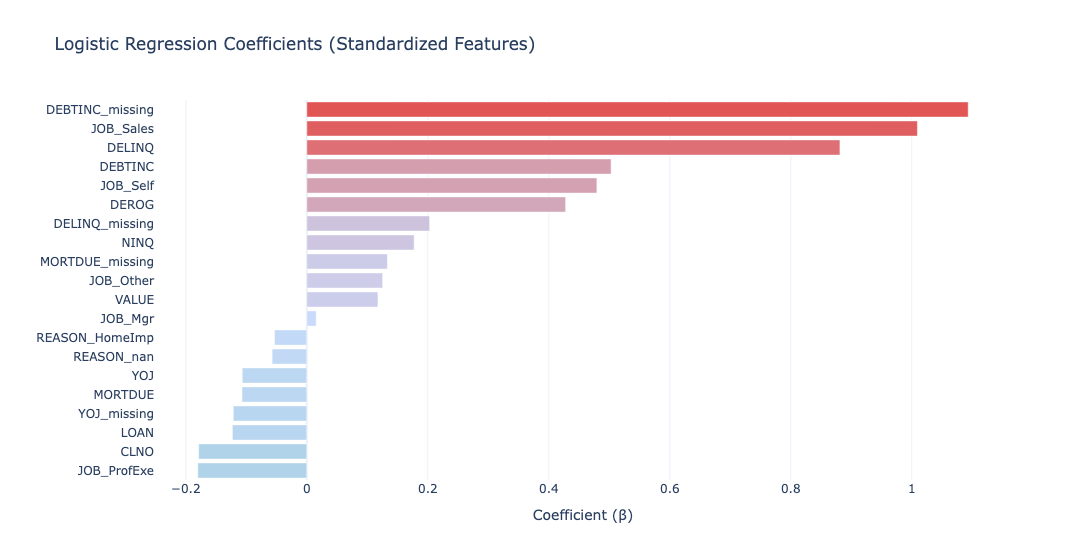

  Saved: outputs/logistic_regression/coefficients.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/logistic_regression/coefficients.html')

In [5]:
# Coefficient chart
coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": lr_model.coef_[0],
    "odds_ratio": np.exp(lr_model.coef_[0]),
}).sort_values("coefficient", ascending=True)

fig_coef = px.bar(
    coef_df.tail(20), x="coefficient", y="feature", orientation="h",
    title="Logistic Regression Coefficients (Standardized Features)",
    color="coefficient",
    color_continuous_scale=[[0, COLORS["green"]], [0.5, COLORS["ice"]], [1, COLORS["red"]]],
    color_continuous_midpoint=0,
    height=max(400, len(coef_df.tail(20)) * 28),
)
fig_coef.update_layout(yaxis_title="", xaxis_title="Coefficient (β)", coloraxis_showscale=False)
fig_coef.show()
save_chart(fig_coef, MODEL_SLUG, "coefficients")

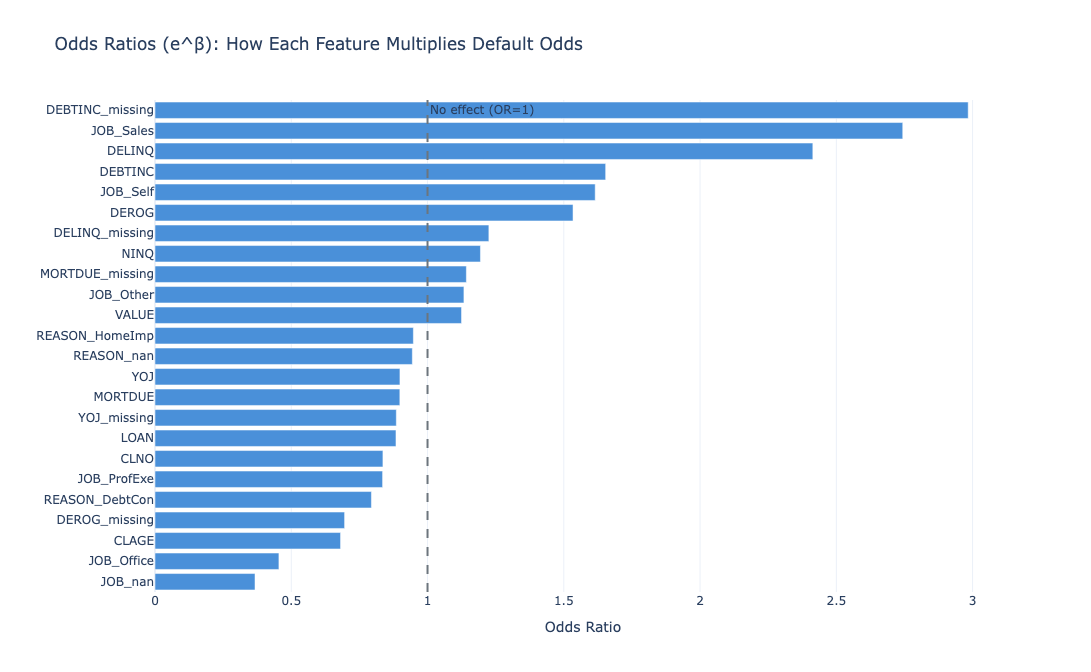

  Saved: outputs/logistic_regression/odds_ratios.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/logistic_regression/odds_ratios.html')

In [6]:
# Odds ratio chart
coef_significant = coef_df[coef_df["coefficient"].abs() > 0.05].copy()
coef_significant = coef_significant.sort_values("odds_ratio", ascending=True)

fig_or = px.bar(
    coef_significant, x="odds_ratio", y="feature", orientation="h",
    title="Odds Ratios (e^β): How Each Feature Multiplies Default Odds",
    height=max(400, len(coef_significant) * 28),
    color_discrete_sequence=[COLORS["accent"]],
)
fig_or.add_vline(x=1.0, line_dash="dash", line_color=COLORS["gray"],
                 annotation_text="No effect (OR=1)")
fig_or.update_layout(yaxis_title="", xaxis_title="Odds Ratio")
fig_or.show()
save_chart(fig_or, MODEL_SLUG, "odds_ratios")

---
## 6. Regularization Path

How do coefficients change as we vary the regularization strength $C$?

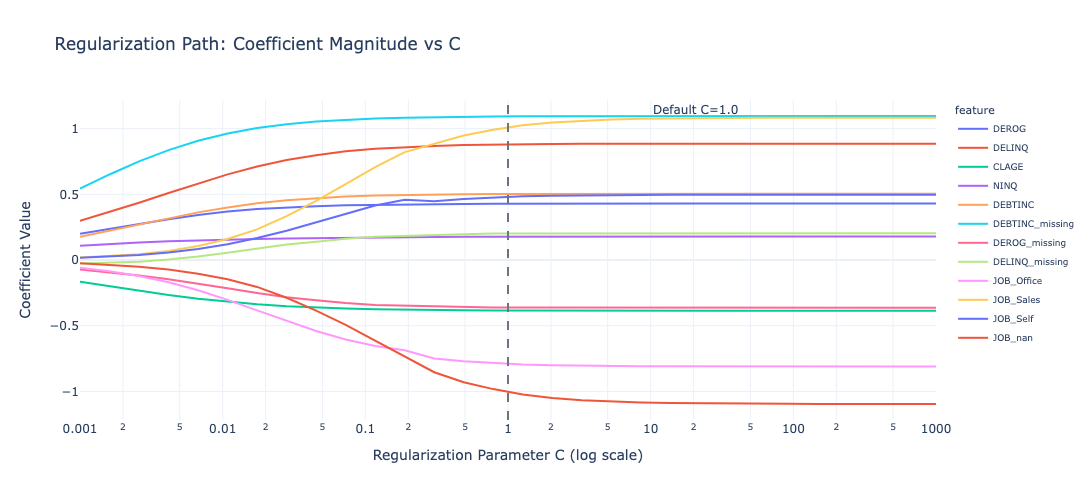

  Saved: outputs/logistic_regression/regularization_path.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/logistic_regression/regularization_path.html')

In [7]:
# Sweep C values
C_values = np.logspace(-3, 3, 30)
coef_paths = []

for c_val in C_values:
    lr_temp = Pipeline([
        ("prep", prep_linear),
        ("clf", LogisticRegression(
            class_weight="balanced", max_iter=2000,
            random_state=RANDOM_STATE, solver="lbfgs", C=c_val
        )),
    ])
    lr_temp.fit(X_train, y_train)
    for j, fname in enumerate(all_feature_names):
        coef_paths.append({
            "C": c_val,
            "feature": fname,
            "coefficient": lr_temp.named_steps["clf"].coef_[0][j],
        })

df_paths = pd.DataFrame(coef_paths)

# Plot top 8 features by final coefficient magnitude
top_features = coef_df.tail(8)["feature"].tolist() + coef_df.head(4)["feature"].tolist()
df_paths_top = df_paths[df_paths["feature"].isin(top_features)]

fig_reg = px.line(
    df_paths_top, x="C", y="coefficient", color="feature",
    log_x=True,
    title="Regularization Path: Coefficient Magnitude vs C",
    labels={"C": "Regularization Parameter C (log scale)", "coefficient": "Coefficient Value"},
    height=500, width=750,
)
fig_reg.add_vline(x=1.0, line_dash="dash", line_color=COLORS["gray"],
                  annotation_text="Default C=1.0")
fig_reg.update_layout(legend=dict(font_size=9))
fig_reg.show()
save_chart(fig_reg, MODEL_SLUG, "regularization_path")

---
## 7. Calibration Curve

Logistic regression is naturally well-calibrated because it directly models probabilities via MLE. The calibration curve shows whether predicted probabilities match observed frequencies.

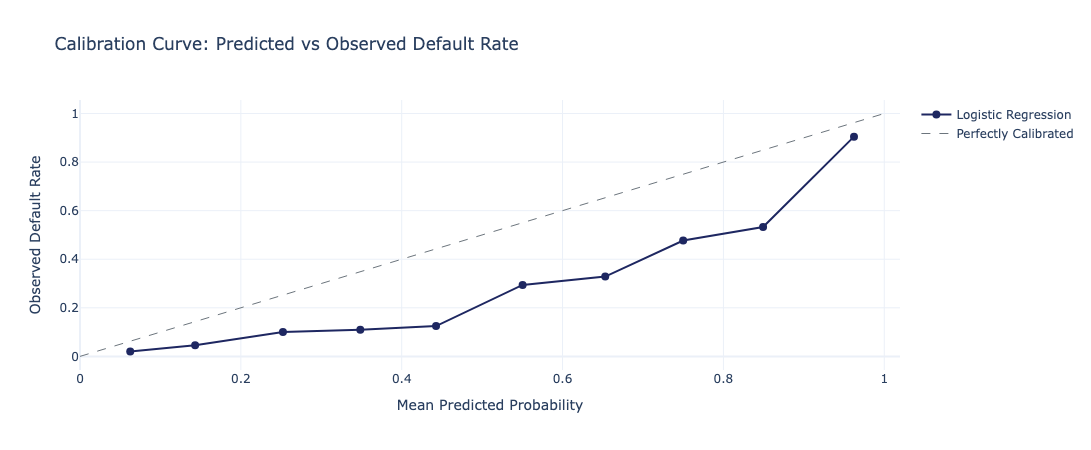

  Saved: outputs/logistic_regression/calibration_curve.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/logistic_regression/calibration_curve.html')

In [8]:
from sklearn.calibration import calibration_curve

y_prob = lr_pipe.predict_proba(X_test)[:, 1]
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy="uniform")

fig_cal = go.Figure()
fig_cal.add_trace(go.Scatter(
    x=prob_pred, y=prob_true, mode="lines+markers",
    name="Logistic Regression",
    line=dict(color=COLORS["navy"], width=2),
    marker=dict(size=8),
))
fig_cal.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1], mode="lines",
    name="Perfectly Calibrated",
    line=dict(color=COLORS["gray"], width=1, dash="dash"),
))
fig_cal.update_layout(
    title="Calibration Curve: Predicted vs Observed Default Rate",
    xaxis_title="Mean Predicted Probability",
    yaxis_title="Observed Default Rate",
    height=450, width=550,
)
fig_cal.show()
save_chart(fig_cal, MODEL_SLUG, "calibration_curve")

---
## 8. Decision Boundary (2D PCA Projection)

Logistic regression creates a linear decision boundary in feature space. Since we have many features, we project to 2D using PCA and visualize where the boundary falls.

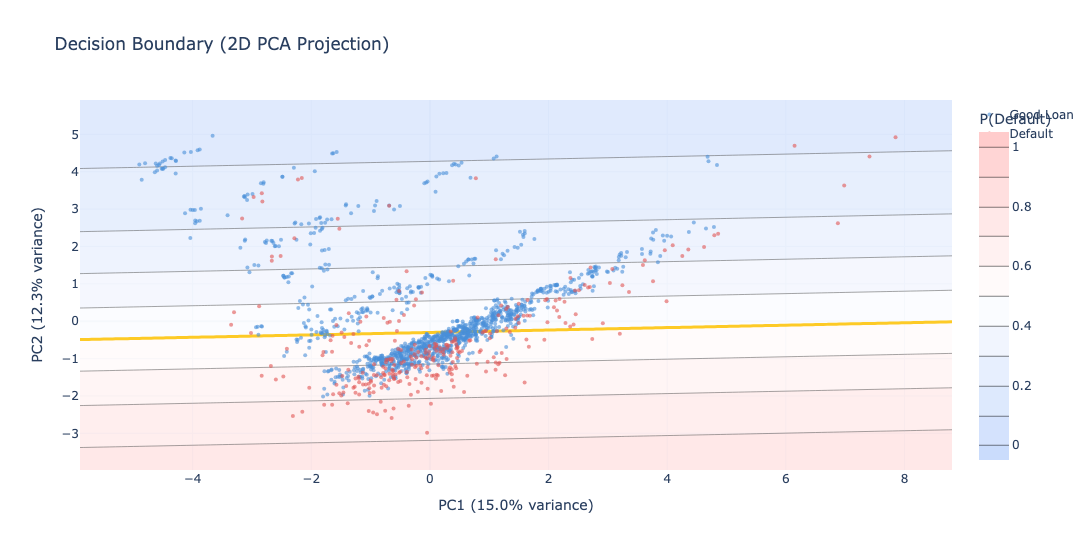

  Saved: outputs/logistic_regression/decision_boundary_2d.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/logistic_regression/decision_boundary_2d.html')

In [9]:
from sklearn.decomposition import PCA

# Transform and reduce to 2D
X_train_transformed = prep_linear.fit_transform(X_train)
X_test_transformed = prep_linear.transform(X_test)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train_transformed)
X_test_2d = pca.transform(X_test_transformed)

# Train LR on 2D
lr_2d = LogisticRegression(class_weight="balanced", max_iter=2000,
                           random_state=RANDOM_STATE, solver="lbfgs")
lr_2d.fit(X_train_2d, y_train)

# Create mesh grid for decision boundary
h = 0.1
x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = lr_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

fig_db = go.Figure()

# Decision boundary contour
fig_db.add_trace(go.Contour(
    x=np.arange(x_min, x_max, h), y=np.arange(y_min, y_max, h), z=Z,
    colorscale=[[0, COLORS["ice"]], [0.5, COLORS["white"]], [1, "#ffcccc"]],
    contours=dict(start=0, end=1, size=0.1),
    showscale=True, colorbar=dict(title="P(Default)"),
    opacity=0.7,
))

# Test points
for label, color, name in [(0, COLORS["accent"], "Good Loan"), (1, COLORS["red"], "Default")]:
    mask = y_test == label
    fig_db.add_trace(go.Scatter(
        x=X_test_2d[mask, 0], y=X_test_2d[mask, 1],
        mode="markers", name=name,
        marker=dict(color=color, size=4, opacity=0.6),
    ))

# Decision boundary line
fig_db.add_trace(go.Contour(
    x=np.arange(x_min, x_max, h), y=np.arange(y_min, y_max, h), z=Z,
    contours=dict(start=0.5, end=0.5, size=0, coloring="lines"),
    line=dict(color=COLORS["navy"], width=3),
    showscale=False, name="Decision Boundary",
))

fig_db.update_layout(
    title="Decision Boundary (2D PCA Projection)",
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)",
    height=550, width=700,
)
fig_db.show()
save_chart(fig_db, MODEL_SLUG, "decision_boundary_2d")

---
## 9. Model Training and Evaluation

We use the same configuration as the capstone: `class_weight='balanced'`, `solver='lbfgs'`, `C=1.0`, `max_iter=2000`.

In [10]:
# Evaluate on test set
metrics, y_pred, y_score = evaluate_model(MODEL_NAME, lr_pipe, X_test, y_test)

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Good Loan", "Default"]))


  Logistic Regression
  Recall: 0.7811  |  Precision: 0.5743  |  F1: 0.6619
  AUC: 0.8844  |  PR-AUC: 0.7498
  Confusion: TP=232 FP=172 FN=65 TN=1021

Classification Report:
              precision    recall  f1-score   support

   Good Loan       0.94      0.86      0.90      1193
     Default       0.57      0.78      0.66       297

    accuracy                           0.84      1490
   macro avg       0.76      0.82      0.78      1490
weighted avg       0.87      0.84      0.85      1490



---
## 10. Diagnostic Charts


Saving universal charts for Logistic Regression:
  Saved: outputs/logistic_regression/roc_curve.html
  Saved: outputs/logistic_regression/precision_recall_curve.html
  Saved: outputs/logistic_regression/confusion_matrix.html
  Saved: outputs/logistic_regression/threshold_sweep.html


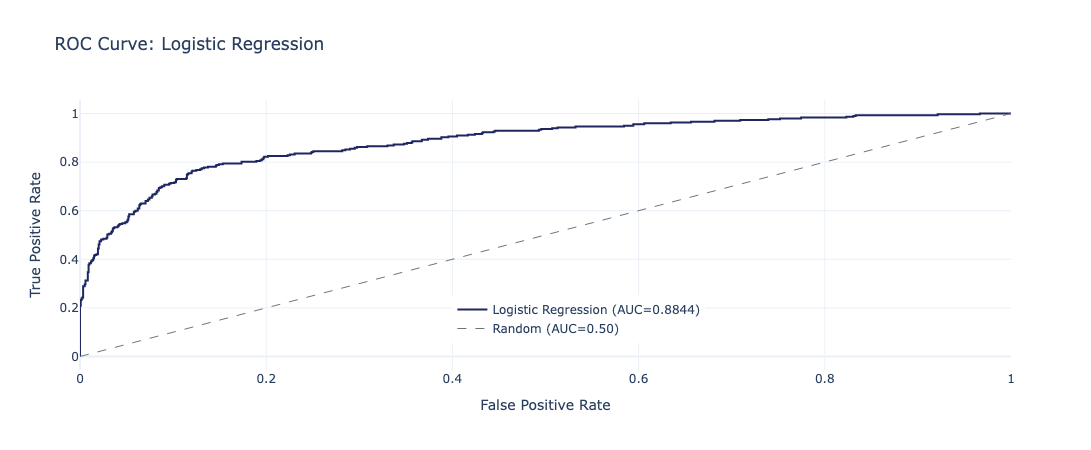

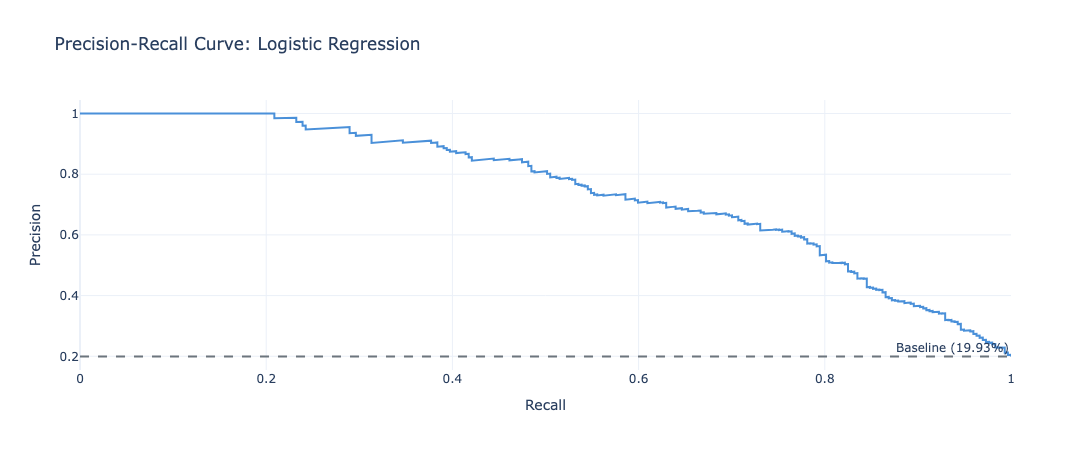

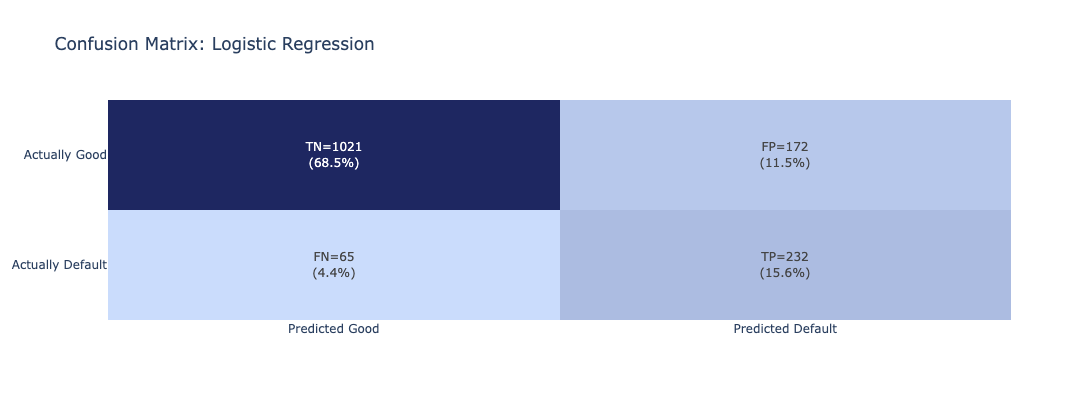

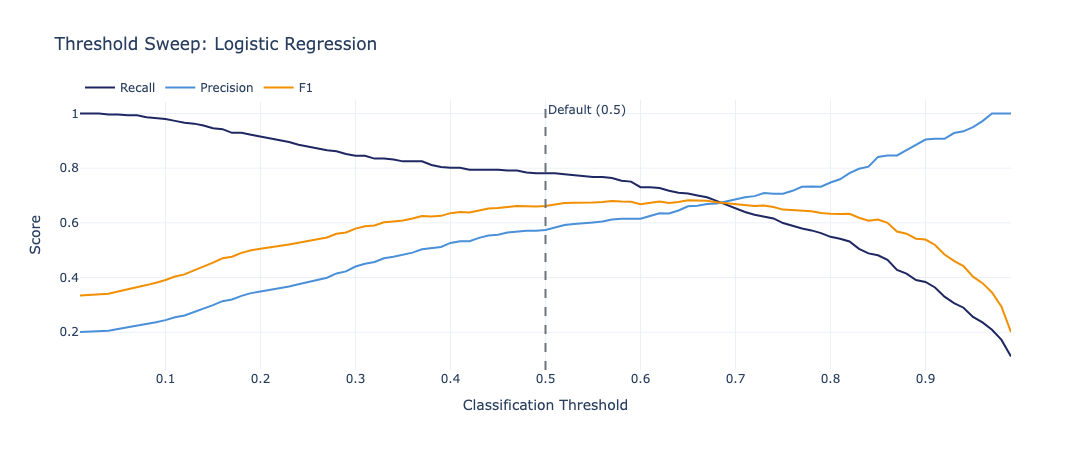

In [11]:
# Generate and save all universal charts
charts = save_all_universal_charts(y_test, y_pred, y_score, MODEL_NAME, MODEL_SLUG)

# Show them inline too
for name, fig in charts.items():
    fig.show()

---
## 11. Predicted Probability Distribution

How are the model's predicted probabilities distributed across the two classes?

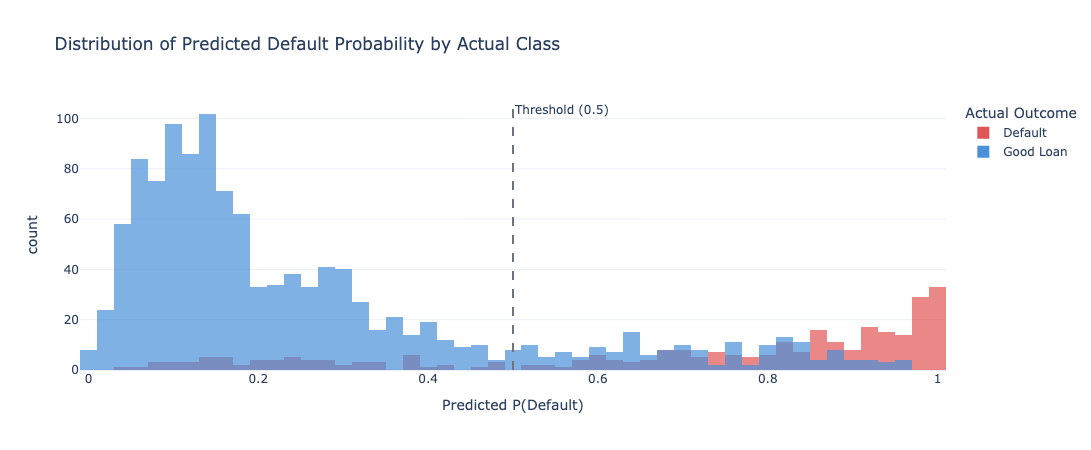

  Saved: outputs/logistic_regression/probability_distribution.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/logistic_regression/probability_distribution.html')

In [12]:
# Probability distribution by actual class
prob_df = pd.DataFrame({
    "probability": y_score,
    "actual": y_test.map({0: "Good Loan", 1: "Default"}).values,
})

fig_prob = px.histogram(
    prob_df, x="probability", color="actual",
    nbins=50, barmode="overlay", opacity=0.7,
    title="Distribution of Predicted Default Probability by Actual Class",
    labels={"probability": "Predicted P(Default)", "actual": "Actual Outcome"},
    color_discrete_map={"Good Loan": COLORS["accent"], "Default": COLORS["red"]},
    height=450, width=650,
)
fig_prob.add_vline(x=0.5, line_dash="dash", line_color=COLORS["gray"],
                   annotation_text="Threshold (0.5)")
fig_prob.show()
save_chart(fig_prob, MODEL_SLUG, "probability_distribution")

---
## 12. Summary

### Where Logistic Regression Sits on the Tradeoff Spectrum

Logistic regression with `class_weight="balanced"` tends toward the **aggressive end** of the spectrum (higher recall, lower precision). The balanced weights push the decision boundary to catch more defaults at the cost of more false positives.

### Strengths for This Problem
- Directly outputs well-calibrated probabilities
- Coefficients are interpretable (odds ratios have business meaning)
- Fast to train, easy to explain to stakeholders
- Regularization prevents overfitting

### Limitations for This Problem
- Assumes a linear relationship between features and log-odds
- Cannot capture interactions without manual feature engineering
- May underperform on datasets with complex nonlinear patterns
- Sensitive to multicollinearity among features

### Key Takeaway
Logistic regression is the **interpretable baseline**. If a more complex model cannot meaningfully beat it, there is no justification for the added complexity. The odds ratios tell a clear business story: which features drive default risk and by how much.

---
*Notebook by Trinidad Cisneros — MIT Applied Data Science Program, April 2026*